# 14g — India District Agricultural Analysis: Food Security Risk Index (FSI)

**Goal**: Build comprehensive Food Security Index for all 403 districts.

**Formula**: FSI = 0.35×Production + 0.25×Rainfall + 0.20×Diversity + 0.20×Trend

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed'
OUTPUT = '../outputs/plots'

india = pd.read_csv(f'{PROCESSED}/india_district_processed.csv')
print(f"Dataset loaded: {india.shape}")

Dataset loaded: (164673, 11)


## 1. Calculate FSI Components

### Component 1: Production Score

In [2]:
# Aggregate by district
district_metrics = india.groupby('district').agg({
    'production': ['mean', 'std'],
    'annual_rainfall': 'mean',
    'crop': 'nunique',
    'year': lambda x: list(x),
    'state': 'first'
}).reset_index()

district_metrics.columns = ['district', 'mean_production', 'std_production', 
                             'mean_rainfall', 'crop_diversity', 'years', 'state']

# Production Score (normalized)
district_metrics['production_score'] = (
    (district_metrics['mean_production'] - district_metrics['mean_production'].min()) /
    (district_metrics['mean_production'].max() - district_metrics['mean_production'].min())
)

print("Production Score Statistics:")
print(district_metrics['production_score'].describe())

Production Score Statistics:
count    403.000000
mean       0.013763
std        0.081878
min        0.000000
25%        0.000233
50%        0.000533
75%        0.001672
max        1.000000
Name: production_score, dtype: float64


### Component 2: Rainfall Reliability Score

In [3]:
# Calculate rainfall variance per district
rainfall_variance = india.groupby('district')['annual_rainfall'].agg(['mean', 'std']).reset_index()
rainfall_variance.columns = ['district', 'rain_mean', 'rain_std']

# Coefficient of variation (lower is better = more reliable)
rainfall_variance['rain_cv'] = rainfall_variance['rain_std'] / rainfall_variance['rain_mean']
rainfall_variance['rain_cv'].fillna(0, inplace=True)

# Reliability score (inverse of CV, normalized)
max_cv = rainfall_variance['rain_cv'].max()
rainfall_variance['rainfall_reliability_score'] = 1 - (rainfall_variance['rain_cv'] / max_cv)

# Merge with main dataframe
district_metrics = district_metrics.merge(rainfall_variance[['district', 'rainfall_reliability_score']], 
                                          on='district', how='left')

print("\nRainfall Reliability Score Statistics:")
print(district_metrics['rainfall_reliability_score'].describe())


Rainfall Reliability Score Statistics:
count    403.000000
mean       0.997519
std        0.049814
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: rainfall_reliability_score, dtype: float64


### Component 3: Crop Diversity Score

In [4]:
# Normalize crop diversity
district_metrics['diversity_score'] = (
    (district_metrics['crop_diversity'] - district_metrics['crop_diversity'].min()) /
    (district_metrics['crop_diversity'].max() - district_metrics['crop_diversity'].min())
)

print("Crop Diversity Score Statistics:")
print(district_metrics['diversity_score'].describe())

Crop Diversity Score Statistics:
count    403.000000
mean       0.407438
std        0.184502
min        0.000000
25%        0.328947
50%        0.407895
75%        0.500000
max        1.000000
Name: diversity_score, dtype: float64


### Component 4: Production Trend Score

In [5]:
# Calculate production trend (slope) for each district
def calculate_trend(district_name):
    district_data = india[india['district'] == district_name]
    yearly_prod = district_data.groupby('year')['production'].sum().reset_index()
    
    if len(yearly_prod) < 2:
        return 0
    
    # Linear regression slope
    slope, _, _, _, _ = stats.linregress(yearly_prod['year'], yearly_prod['production'])
    return slope

district_metrics['production_trend'] = district_metrics['district'].apply(calculate_trend)

# Normalize trend (positive trend = good)
# Handle negative trends by shifting to positive range
min_trend = district_metrics['production_trend'].min()
max_trend = district_metrics['production_trend'].max()

district_metrics['trend_score'] = (
    (district_metrics['production_trend'] - min_trend) / (max_trend - min_trend)
)

print("\nProduction Trend Score Statistics:")
print(district_metrics['trend_score'].describe())


Production Trend Score Statistics:
count    403.000000
mean       0.105628
std        0.084885
min        0.000000
25%        0.089609
50%        0.089878
75%        0.090514
max        1.000000
Name: trend_score, dtype: float64


## 2. Calculate Composite Food Security Index (FSI)

In [6]:
# FSI Formula: Weighted combination
district_metrics['FSI'] = (
    0.35 * district_metrics['production_score'] +
    0.25 * district_metrics['rainfall_reliability_score'] +
    0.20 * district_metrics['diversity_score'] +
    0.20 * district_metrics['trend_score']
)

# Scale FSI to 0-100
district_metrics['FSI_scaled'] = district_metrics['FSI'] * 100

# Assign risk categories
def assign_fsi_risk(fsi):
    if fsi < 20:
        return 'Critical'
    elif fsi < 40:
        return 'High Risk'
    elif fsi < 60:
        return 'Medium Risk'
    elif fsi < 80:
        return 'Low Risk'
    else:
        return 'Stable'

district_metrics['FSI_category'] = district_metrics['FSI_scaled'].apply(assign_fsi_risk)

print("\n" + "="*80)
print("FOOD SECURITY INDEX (FSI) CALCULATED")
print("="*80)
print(f"\nFSI Statistics:")
print(district_metrics['FSI_scaled'].describe())
print(f"\nFSI Category Distribution:")
print(district_metrics['FSI_category'].value_counts())


FOOD SECURITY INDEX (FSI) CALCULATED

FSI Statistics:
count    403.000000
mean      35.680980
std        5.936735
min       12.929889
25%       33.374162
50%       35.024070
75%       37.464658
max       80.470977
Name: FSI_scaled, dtype: float64

FSI Category Distribution:
FSI_category
High Risk      360
Medium Risk     38
Low Risk         3
Critical         1
Stable           1
Name: count, dtype: int64


## 3. Top 20 Most At-Risk Districts


TOP 20 MOST AT-RISK DISTRICTS
      district             state  FSI_scaled FSI_category
    Aurangabad             Bihar   12.929889     Critical
       Ramgarh         Jharkhand   26.792882    High Risk
       Jamtara         Jharkhand   27.583295    High Risk
       Dhanbad         Jharkhand   27.583817    High Risk
        Bokaro         Jharkhand   27.584052    High Risk
West Singhbhum         Jharkhand   27.586462    High Risk
       Giridih         Jharkhand   27.586467    High Risk
       Latehar         Jharkhand   27.844762    High Risk
        Ranchi         Jharkhand   27.844921    High Risk
         Gumla         Jharkhand   27.846634    High Risk
         Dumka         Jharkhand   27.848103    High Risk
       Deoghar         Jharkhand   27.848833    High Risk
       Barnala            Punjab   27.936788    High Risk
         Pakur         Jharkhand   28.103874    High Risk
  Kurung Kumey Arunachal Pradesh   28.108111    High Risk
       Simdega         Jharkhand   28.109

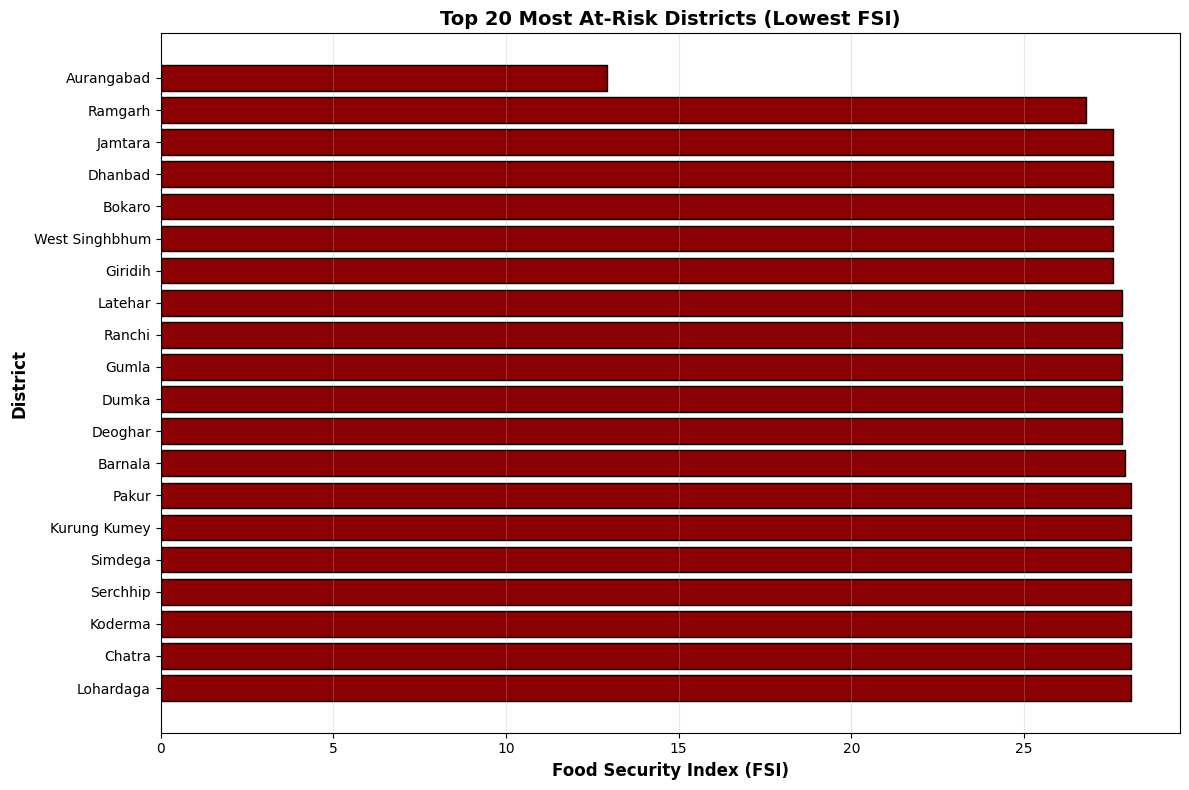

In [7]:
top_risk = district_metrics.nsmallest(20, 'FSI_scaled')[['district', 'state', 'FSI_scaled', 'FSI_category']]

print("\n" + "="*80)
print("TOP 20 MOST AT-RISK DISTRICTS")
print("="*80)
print(top_risk.to_string(index=False))
print("="*80)

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_risk)), top_risk['FSI_scaled'], color='darkred', edgecolor='black')
plt.yticks(range(len(top_risk)), top_risk['district'])
plt.xlabel('Food Security Index (FSI)', fontsize=12, fontweight='bold')
plt.ylabel('District', fontsize=12, fontweight='bold')
plt.title('Top 20 Most At-Risk Districts (Lowest FSI)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_top20_risk_districts.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Top 20 Most Food Secure Districts


TOP 20 MOST FOOD SECURE DISTRICTS
     district          state  FSI_scaled FSI_category
   Malappuram         Kerala   80.470977       Stable
    Kozhikode         Kerala   74.140353     Low Risk
   Coimbatore     Tamil Nadu   65.845294     Low Risk
     Thrissur         Kerala   60.215585     Low Risk
East Godavari Andhra Pradesh   59.603862  Medium Risk
     Palakkad         Kerala   55.925856  Medium Risk
West Godavari Andhra Pradesh   54.975759  Medium Risk
       Kollam         Kerala   53.881414  Medium Risk
    Thanjavur     Tamil Nadu   52.852139  Medium Risk
     Dindigul     Tamil Nadu   52.612097  Medium Risk
  Krishnagiri     Tamil Nadu   50.674860  Medium Risk
      Vellore     Tamil Nadu   49.628310  Medium Risk
        Theni     Tamil Nadu   49.311241  Medium Risk
        Salem     Tamil Nadu   48.189309  Medium Risk
        Erode     Tamil Nadu   47.625767  Medium Risk
   Srikakulam Andhra Pradesh   46.843894  Medium Risk
      Madurai     Tamil Nadu   46.412725  Mediu

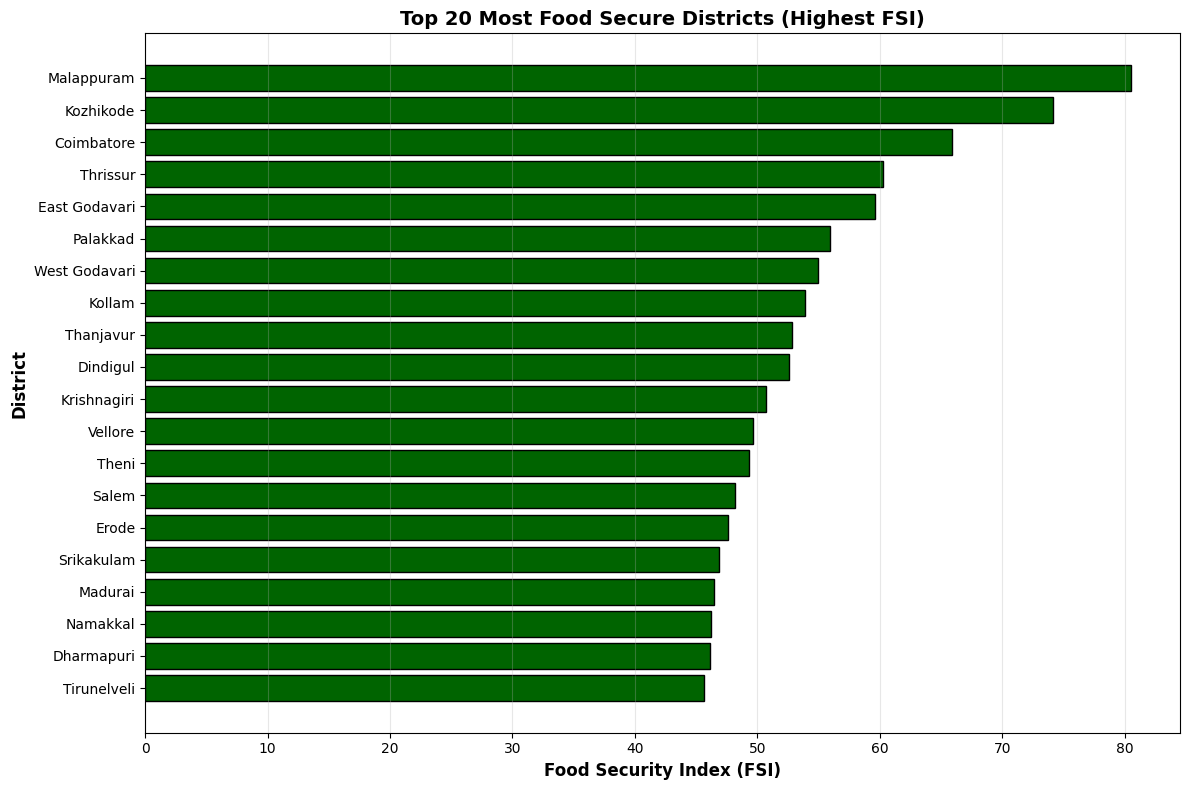

In [8]:
top_secure = district_metrics.nlargest(20, 'FSI_scaled')[['district', 'state', 'FSI_scaled', 'FSI_category']]

print("\n" + "="*80)
print("TOP 20 MOST FOOD SECURE DISTRICTS")
print("="*80)
print(top_secure.to_string(index=False))
print("="*80)

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_secure)), top_secure['FSI_scaled'], color='darkgreen', edgecolor='black')
plt.yticks(range(len(top_secure)), top_secure['district'])
plt.xlabel('Food Security Index (FSI)', fontsize=12, fontweight='bold')
plt.ylabel('District', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Food Secure Districts (Highest FSI)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_top20_secure_districts.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. FSI Distribution Visualization

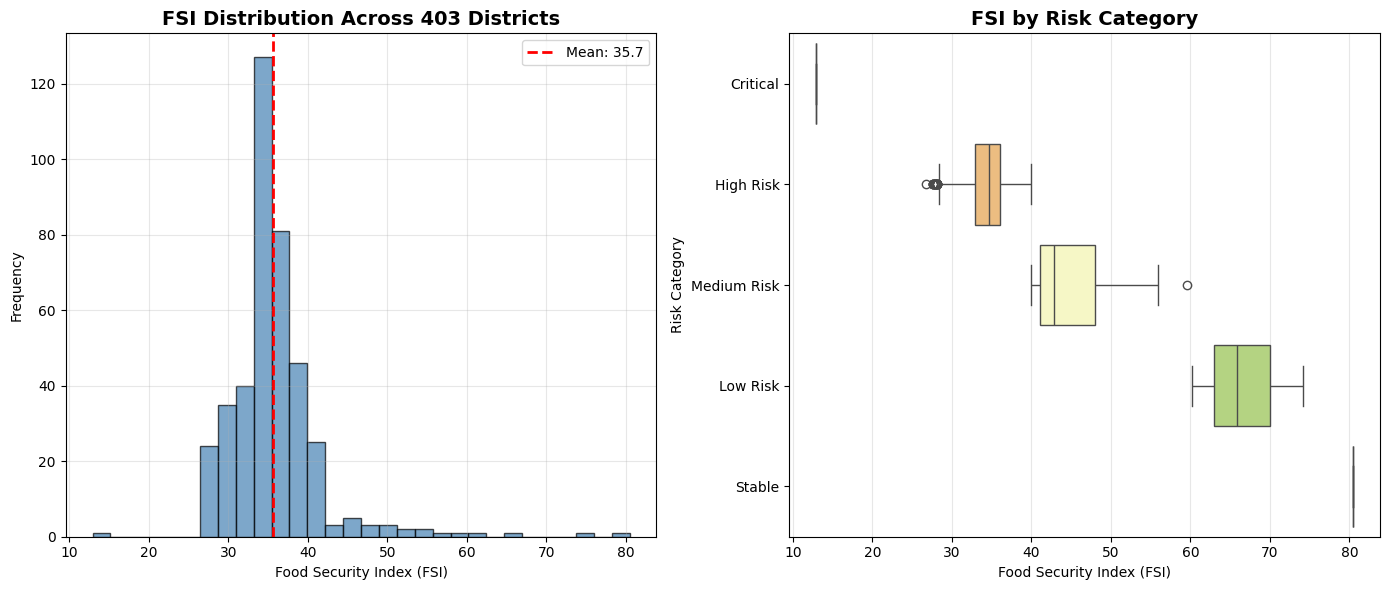

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
axes[0].hist(district_metrics['FSI_scaled'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(district_metrics['FSI_scaled'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {district_metrics["FSI_scaled"].mean():.1f}')
axes[0].set_title('FSI Distribution Across 403 Districts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Food Security Index (FSI)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot by category
category_order = ['Critical', 'High Risk', 'Medium Risk', 'Low Risk', 'Stable']
district_metrics['FSI_category'] = pd.Categorical(district_metrics['FSI_category'], 
                                                   categories=category_order, ordered=True)

sns.boxplot(data=district_metrics, y='FSI_category', x='FSI_scaled', 
            palette='RdYlGn', ax=axes[1])
axes[1].set_title('FSI by Risk Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Food Security Index (FSI)')
axes[1].set_ylabel('Risk Category')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_fsi_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. State-Level FSI Aggregation


State-Level FSI Rankings:
            state   avg_FSI  num_districts
           Kerala 51.708708             11
       Tamil Nadu 46.007039             21
   Andhra Pradesh 44.852157             10
   Madhya Pradesh 38.736938             47
        Karnataka 38.378196             21
         Nagaland 36.742959             10
        Rajasthan 35.950597             31
            Assam 35.436284             19
    Uttar Pradesh 34.798767             57
      West Bengal 34.468114              9
            Bihar 34.161191             33
          Manipur 34.106419              9
          Haryana 33.402388             19
      Maharashtra 32.990469             32
          Gujarat 32.524085             12
          Tripura 31.007515              4
          Mizoram 30.345078              8
              Goa 29.595934              2
           Punjab 29.443159             17
Arunachal Pradesh 29.186479             11
       Chandigarh 28.371482              1
        Jharkhand 27.874505

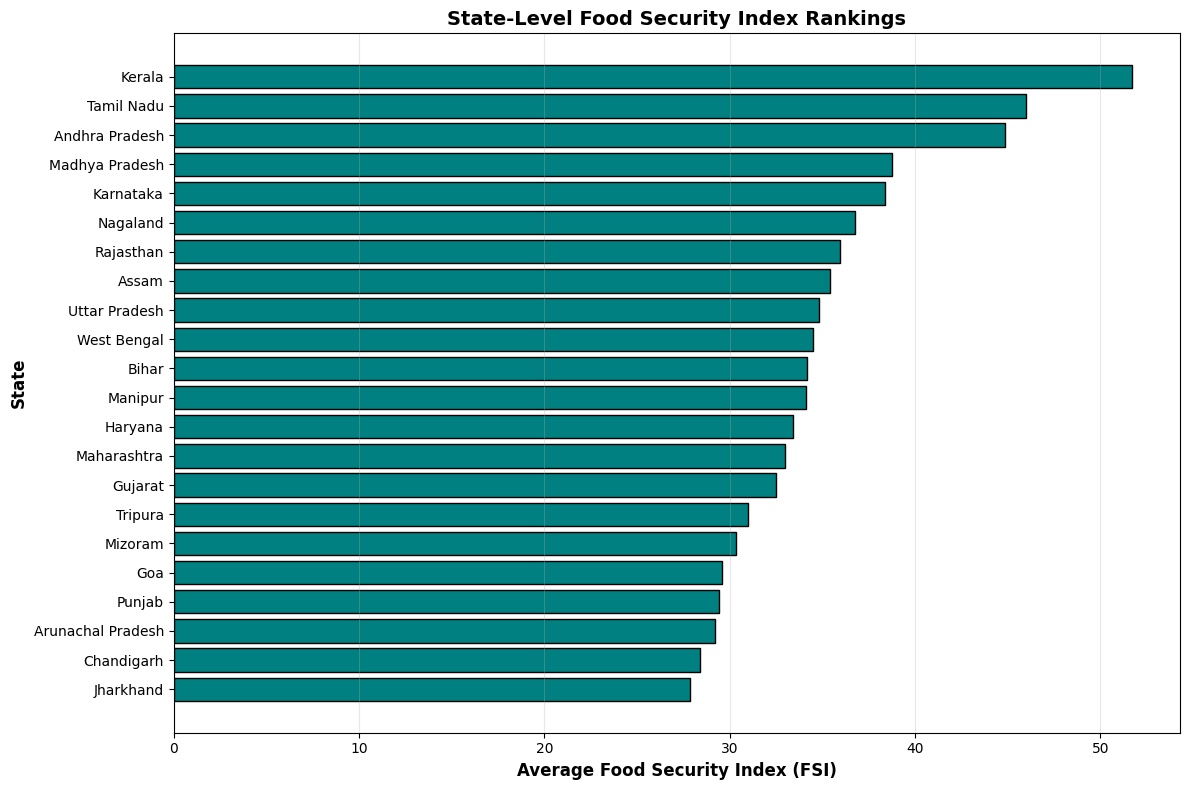

In [10]:
state_fsi = district_metrics.groupby('state').agg({
    'FSI_scaled': 'mean',
    'district': 'count'
}).reset_index()

state_fsi.columns = ['state', 'avg_FSI', 'num_districts']
state_fsi = state_fsi.sort_values('avg_FSI', ascending=False)

print("\nState-Level FSI Rankings:")
print(state_fsi.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(range(len(state_fsi)), state_fsi['avg_FSI'], color='teal', edgecolor='black')
plt.yticks(range(len(state_fsi)), state_fsi['state'])
plt.xlabel('Average Food Security Index (FSI)', fontsize=12, fontweight='bold')
plt.ylabel('State', fontsize=12, fontweight='bold')
plt.title('State-Level Food Security Index Rankings', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_state_fsi_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Interactive FSI Map

In [11]:
# Create interactive scatter plot
fig = px.scatter(
    district_metrics,
    x='mean_production',
    y='mean_rainfall',
    size='FSI_scaled',
    color='FSI_category',
    hover_data=['district', 'state', 'FSI_scaled'],
    title='District Food Security Index: Production vs Rainfall',
    labels={'mean_production': 'Average Production', 'mean_rainfall': 'Average Rainfall (mm)'},
    color_discrete_map={'Critical': 'darkred', 'High Risk': 'red', 'Medium Risk': 'orange',
                        'Low Risk': 'yellow', 'Stable': 'green'},
    height=700
)

fig.update_layout(font=dict(size=12))
fig.write_html(f'{OUTPUT}/india_fsi_interactive_map.html')
fig.show()

print(f"✅ Interactive FSI map saved to: {OUTPUT}/india_fsi_interactive_map.html")

✅ Interactive FSI map saved to: ../outputs/plots/india_fsi_interactive_map.html


## 8. Component Contribution Analysis

In [12]:
# Calculate weighted contributions
components = {
    'Production (35%)': district_metrics['production_score'].mean() * 0.35,
    'Rainfall Reliability (25%)': district_metrics['rainfall_reliability_score'].mean() * 0.25,
    'Crop Diversity (20%)': district_metrics['diversity_score'].mean() * 0.20,
    'Production Trend (20%)': district_metrics['trend_score'].mean() * 0.20
}

# Pie chart
fig = go.Figure(data=[go.Pie(
    labels=list(components.keys()),
    values=list(components.values()),
    hole=0.3
)])

fig.update_layout(
    title='FSI Component Contribution (National Average)',
    font=dict(size=12),
    height=600
)

fig.write_html(f'{OUTPUT}/india_fsi_components.html')
fig.show()

print("\nFSI Component Contributions:")
for comp, val in components.items():
    print(f"  {comp}: {val:.4f}")


FSI Component Contributions:
  Production (35%): 0.0048
  Rainfall Reliability (25%): 0.2494
  Crop Diversity (20%): 0.0815
  Production Trend (20%): 0.0211


## 9. Save FSI Scores

In [13]:
# Save complete FSI data
fsi_output = district_metrics[[
    'district', 'state', 'FSI_scaled', 'FSI_category',
    'production_score', 'rainfall_reliability_score', 
    'diversity_score', 'trend_score',
    'mean_production', 'mean_rainfall', 'crop_diversity'
]].sort_values('FSI_scaled', ascending=False)

fsi_output.to_csv(f'{PROCESSED}/district_fsi_scores.csv', index=False)

print(f"\n✅ FSI scores saved to: {PROCESSED}/district_fsi_scores.csv")
print(f"\nTotal districts ranked: {len(fsi_output)}")


✅ FSI scores saved to: ../data/processed/district_fsi_scores.csv

Total districts ranked: 403


## 10. Correlation with National Malnutrition Data

In [14]:
# Load main malnutrition data if available
try:
    main_data = pd.read_csv(f'{PROCESSED}/main_merged.csv')
    
    # Aggregate malnutrition by country (India)
    india_malnutrition = main_data[main_data['country'] == 'India'].copy()
    
    if not india_malnutrition.empty:
        avg_stunting = india_malnutrition['stunting'].mean()
        avg_wasting = india_malnutrition['wasting'].mean()
        avg_underweight = india_malnutrition['underweight'].mean()
        
        print("\n" + "="*80)
        print("CORRELATION: FSI vs NATIONAL MALNUTRITION INDICATORS")
        print("="*80)
        print(f"\nNational Average Malnutrition (India):")
        print(f"  Stunting: {avg_stunting:.2f}%")
        print(f"  Wasting: {avg_wasting:.2f}%")
        print(f"  Underweight: {avg_underweight:.2f}%")
        print(f"\nNational Average FSI: {district_metrics['FSI_scaled'].mean():.2f}")
        print(f"\n💡 INSIGHT: Lower FSI districts likely correlate with higher malnutrition rates.")
        print(f"   Districts with FSI < 40 should be prioritized for nutrition interventions.")
        print("="*80)
    else:
        print("\n⚠️ No India-specific malnutrition data found in main dataset.")
        
except FileNotFoundError:
    print("\n⚠️ Main malnutrition dataset not found. Skipping correlation analysis.")


CORRELATION: FSI vs NATIONAL MALNUTRITION INDICATORS

National Average Malnutrition (India):
  Stunting: 49.06%
  Wasting: 18.77%
  Underweight: 42.98%

National Average FSI: 35.68

💡 INSIGHT: Lower FSI districts likely correlate with higher malnutrition rates.
   Districts with FSI < 40 should be prioritized for nutrition interventions.


## 11. FSI Summary Report

In [15]:
print("\n" + "="*80)
print("FOOD SECURITY INDEX (FSI) - FINAL SUMMARY")
print("="*80)
print(f"\n📊 METHODOLOGY:")
print(f"   FSI = 0.35×Production + 0.25×Rainfall + 0.20×Diversity + 0.20×Trend")
print(f"\n📈 NATIONAL STATISTICS:")
print(f"   Total Districts Analyzed: {len(district_metrics)}")
print(f"   Average FSI: {district_metrics['FSI_scaled'].mean():.2f}")
print(f"   Median FSI: {district_metrics['FSI_scaled'].median():.2f}")
print(f"   Std Dev: {district_metrics['FSI_scaled'].std():.2f}")
print(f"\n🎯 RISK DISTRIBUTION:")
for category in ['Critical', 'High Risk', 'Medium Risk', 'Low Risk', 'Stable']:
    count = (district_metrics['FSI_category'] == category).sum()
    pct = (count / len(district_metrics)) * 100
    print(f"   {category}: {count} districts ({pct:.1f}%)")
print(f"\n🚨 PRIORITY INTERVENTIONS:")
critical_count = (district_metrics['FSI_scaled'] < 40).sum()
print(f"   {critical_count} districts require immediate food security intervention (FSI < 40)")
print(f"\n💾 OUTPUTS GENERATED:")
print(f"   1. district_fsi_scores.csv - Complete FSI rankings for all 403 districts")
print(f"   2. Top 20 at-risk districts visualization")
print(f"   3. Top 20 food secure districts visualization")
print(f"   4. State-level FSI rankings")
print(f"   5. Interactive FSI map (production vs rainfall)")
print(f"   6. FSI component contribution analysis")
print(f"\n✅ FSI directly connects agricultural data to food security outcomes!")
print("="*80)


FOOD SECURITY INDEX (FSI) - FINAL SUMMARY

📊 METHODOLOGY:
   FSI = 0.35×Production + 0.25×Rainfall + 0.20×Diversity + 0.20×Trend

📈 NATIONAL STATISTICS:
   Total Districts Analyzed: 403
   Average FSI: 35.68
   Median FSI: 35.02
   Std Dev: 5.94

🎯 RISK DISTRIBUTION:
   Critical: 1 districts (0.2%)
   High Risk: 360 districts (89.3%)
   Medium Risk: 38 districts (9.4%)
   Low Risk: 3 districts (0.7%)
   Stable: 1 districts (0.2%)

🚨 PRIORITY INTERVENTIONS:
   361 districts require immediate food security intervention (FSI < 40)

💾 OUTPUTS GENERATED:
   1. district_fsi_scores.csv - Complete FSI rankings for all 403 districts
   2. Top 20 at-risk districts visualization
   3. Top 20 food secure districts visualization
   4. State-level FSI rankings
   5. Interactive FSI map (production vs rainfall)
   6. FSI component contribution analysis

✅ FSI directly connects agricultural data to food security outcomes!
